In [1]:
import sys,os
sys.path.append('../../')
os.environ["JAX_PLATFORMS"] = "cpu"
import matplotlib.pyplot as plt
import numpy as np
from utils import makefolder,get_acronym,depths,reduce_list_half_preserve_extremes

from geometry import * 

eps = 1E-7
rcpsize = 12
plt.rcParams['xtick.labelsize']= rcpsize
plt.rcParams['ytick.labelsize']=rcpsize
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['font.family'] = 'STIXGeneral'
plt.rcParams['font.size'] = rcpsize
plt.rcParams.update({'figure.autolayout': True})
#colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
colors = plt.style.library['ggplot']['axes.prop_cycle'].by_key()['color']
colors = plt.style.library['seaborn-v0_8']['axes.prop_cycle'].by_key()['color']
colors = plt.style.library['seaborn-v0_8-dark-palette']['axes.prop_cycle'].by_key()['color']
from cycler import cycler
plt.rcParams['axes.prop_cycle'] = cycler(color=colors)
# print(plt.rcParams.keys())
#np.set_printoptions(precision=None)
markers = ['p','o','h','^','s','*']
_linestyles = ['-','--','dotted']
plot_id = 0

In [2]:
# modelA = 'deepseek'
modelA = 'llama'
modelB = modelA
language_pairs = [('english','spanish'),
                  ]
aux_A = 'source'
aux_B = 'target'

batch_shuffle = 0
min_token_length = 7
n_files = 20
batch_size = 100
Ns = batch_size*n_files
n_tokens_list = [7]
avg = 0
Nbits_list = [0,1]

idx = None
match_vars = ['matching']

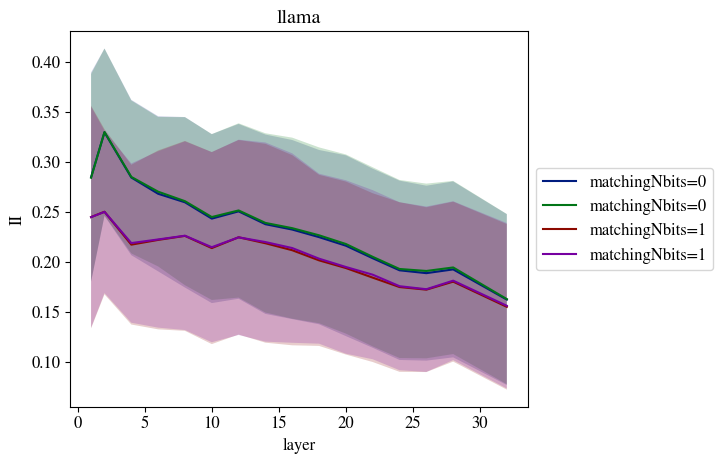

In [3]:
fig,ax = plt.subplots(1)

for match_id,match_var in enumerate(match_vars):
  for Nbits_id,Nbits in enumerate(Nbits_list):
    for language_pair_id, language_pair in enumerate(language_pairs):
      for n_tokens in n_tokens_list:
        (languageA,languageB) = language_pair
        output_folder0 = makefolder(base=f'./results/',
                                      create_folder=False,
                                      modelA=modelA,
                                      modelB=modelB,
                                      match_var=match_var,
                                      n_files=n_files,
                                      min_token_length=min_token_length,
                                      )
        II_folder = makefolder(base=output_folder0,
                                          create_folder=False,
                                          Nbits=Nbits,
                                          n_tokens=n_tokens,
                                          avg_tokens=avg,
                                          batch_shuffle=batch_shuffle,
                                          )
        inf_imb = np.load(II_folder + "corr_coeff.npy")
        std = np.load(II_folder + "corr_coeff_std.npy")

        layers_A = list(range(1,depths[modelA] + 1))
        layers_B = list(range(1,depths[modelB] + 1))
        layers = reduce_list_half_preserve_extremes(layers_A)
            
        for II_index in range(2):
          plt.plot(layers,
                   inf_imb[II_index].diagonal(),
                   label=match_var+f'{Nbits=}',
                   )
          plt.fill_between(layers,
                          inf_imb[II_index].diagonal() - std[II_index].diagonal(),
                          inf_imb[II_index].diagonal() + std[II_index].diagonal(),
                          alpha=0.2)

ax.legend()
ax.set_xlabel('layer')
ax.set_ylabel('II')
ax.set_title(f'{modelA}')


box = ax.get_position()
ax.set_position([box.x0, box.y0, box.width * 0.8, box.height])
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))

plt.show()

### ranks

In [4]:
layer_A = 1
layer_B = 1
method = 'max'
ranks_folder = makefolder(base=output_folder0+f'ranks/{method}/',
                        create_folder=False,
                        Nbits=Nbits,
                        n_tokens=n_tokens,
                        avg_tokens=avg,
                        batch_shuffle=batch_shuffle,
                        layer_A=layer_A,
                        layer_B=layer_B,
                        )
corr_coeff = build_corr_coeff(average=False)

In [5]:
x_ranks = np.load(os.path.join(ranks_folder, "x_ranks.npy"))
y_ranks = np.load(os.path.join(ranks_folder, "y_ranks.npy"))  
x_l = np.load(os.path.join(ranks_folder, "x_l.npy"))
y_l = np.load(os.path.join(ranks_folder, "y_l.npy"))                        

xi_AB,xi_BA = corr_coeff((x_ranks,y_ranks),(x_l,y_l))

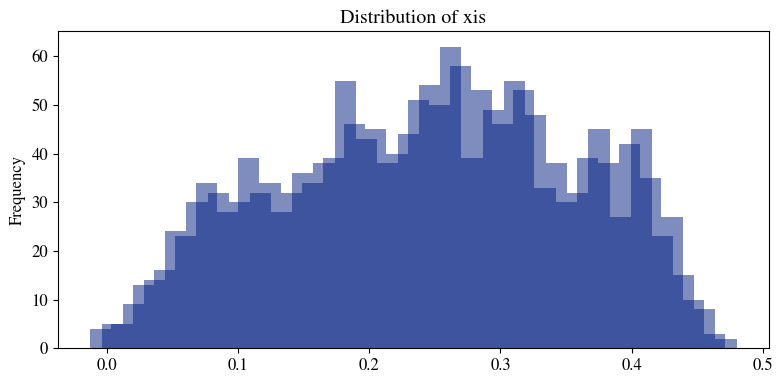

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.hist(np.asarray(xi_BA), bins=30, alpha=0.5, color='C0',label='AB')
plt.hist(np.asarray(xi_AB), bins=30, alpha=0.5, color='C0',label='BA')
plt.ylabel('Frequency')
plt.title('Distribution of xis')
plt.show()

In [7]:
jnp.array([1,2,3])**2

Array([1, 4, 9], dtype=int32)